# Bahnfluss Deutschland Analysis

This notebook explores the scheduled German rail activity generated from the local GTFS feeds. It focuses on the default service date `2026-08-22` and the two downloaded feeds: `Long Distance Rail Germany` and `Regional Rail Germany` from the [gtfs.de feed catalogue](https://gtfs.de/en/feeds/).

The first analysis pass looks at activity over the service day, category share, route mix, and station hub candidates.

## Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from bahnfluss_deutschland.gtfs_activity_stats import create_activity_outputs
from bahnfluss_deutschland.gtfs_basemap import add_germany_map_background
from bahnfluss_deutschland.gtfs_categories import CATEGORY_COLORS, CATEGORY_LABELS, CATEGORY_ORDER, classify_route
from bahnfluss_deutschland.gtfs_static_map import RAIL_ROUTE_TYPES, active_service_ids, parse_service_date
from bahnfluss_deutschland.gtfs_theme import BACKGROUND, FOREGROUND, GRID, MUTED, SPINE, TOTAL
from bahnfluss_deutschland.gtfs_timestamp_frame import default_feeds, style_germany_axis

SERVICE_DATE = parse_service_date("2026-08-22")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS = PROJECT_ROOT / "outputs"

plt.rcParams["figure.facecolor"] = BACKGROUND
plt.rcParams["axes.facecolor"] = BACKGROUND
plt.rcParams["text.color"] = FOREGROUND
plt.rcParams["axes.labelcolor"] = FOREGROUND
plt.rcParams["xtick.color"] = MUTED
plt.rcParams["ytick.color"] = MUTED

## Load Activity Statistics

The CSV is useful because it stores one sampled row per service-day time. That makes analysis fast: we can inspect peaks, lows, shares, and charts without re-reading the large GTFS text files every time.

In [3]:
stats_path = OUTPUTS / f"train_activity_stats_{SERVICE_DATE:%Y-%m-%d}.csv"
plot_path = OUTPUTS / f"train_activity_plot_{SERVICE_DATE:%Y-%m-%d}.png"

if not stats_path.exists() or not plot_path.exists():
    create_activity_outputs(
        DATA_DIR,
        SERVICE_DATE,
        stats_path,
        plot_path,
        step_minutes=1,
    )

stats = pd.read_csv(stats_path)
stats.head()

,service_seconds,service_time,total,regional,s_bahn_local,intercity,high_speed,night_train
0,0,00:00:00,3,1,2,0,0,0
1,60,00:01:00,7,2,5,0,0,0
2,120,00:02:00,15,6,9,0,0,0
3,180,00:03:00,33,14,19,0,0,0
4,240,00:04:00,45,23,22,0,0,0


## Daily Activity Summary

In [4]:
category_columns = [category for category in CATEGORY_ORDER if category in stats.columns]
peak = stats.loc[stats["total"].idxmax()]
low = stats.loc[stats["total"].idxmin()]

train_minutes = stats[category_columns].sum().astype(int)
share = train_minutes / train_minutes.sum()

summary = pd.DataFrame(
    {
        "category": [CATEGORY_LABELS[column] for column in category_columns],
        "train_minutes": train_minutes.values,
        "share": (share.values * 100).round(2),
        "average_active_movements": stats[category_columns].mean().round(1).values,
        "maximum_active_movements": stats[category_columns].max().values,
    }
)

print(f"Peak activity: {int(peak['total']):,} active movements at {peak['service_time']}")
print(f"Lowest activity: {int(low['total']):,} active movements at {low['service_time']}")
display(summary)

Peak activity: 2,318 active movements at 16:48:00
Lowest activity: 3 active movements at 00:00:00


,category,train_minutes,share,average_active_movements,maximum_active_movements
0,regional,1301674,58.03,903.3,1387
1,S-Bahn / local rail,703860,31.38,488.5,691
2,intercity,56114,2.50,38.9,73
3,high-speed,178364,7.95,123.8,216
4,night train,3194,0.14,2.2,14


## Activity Plot

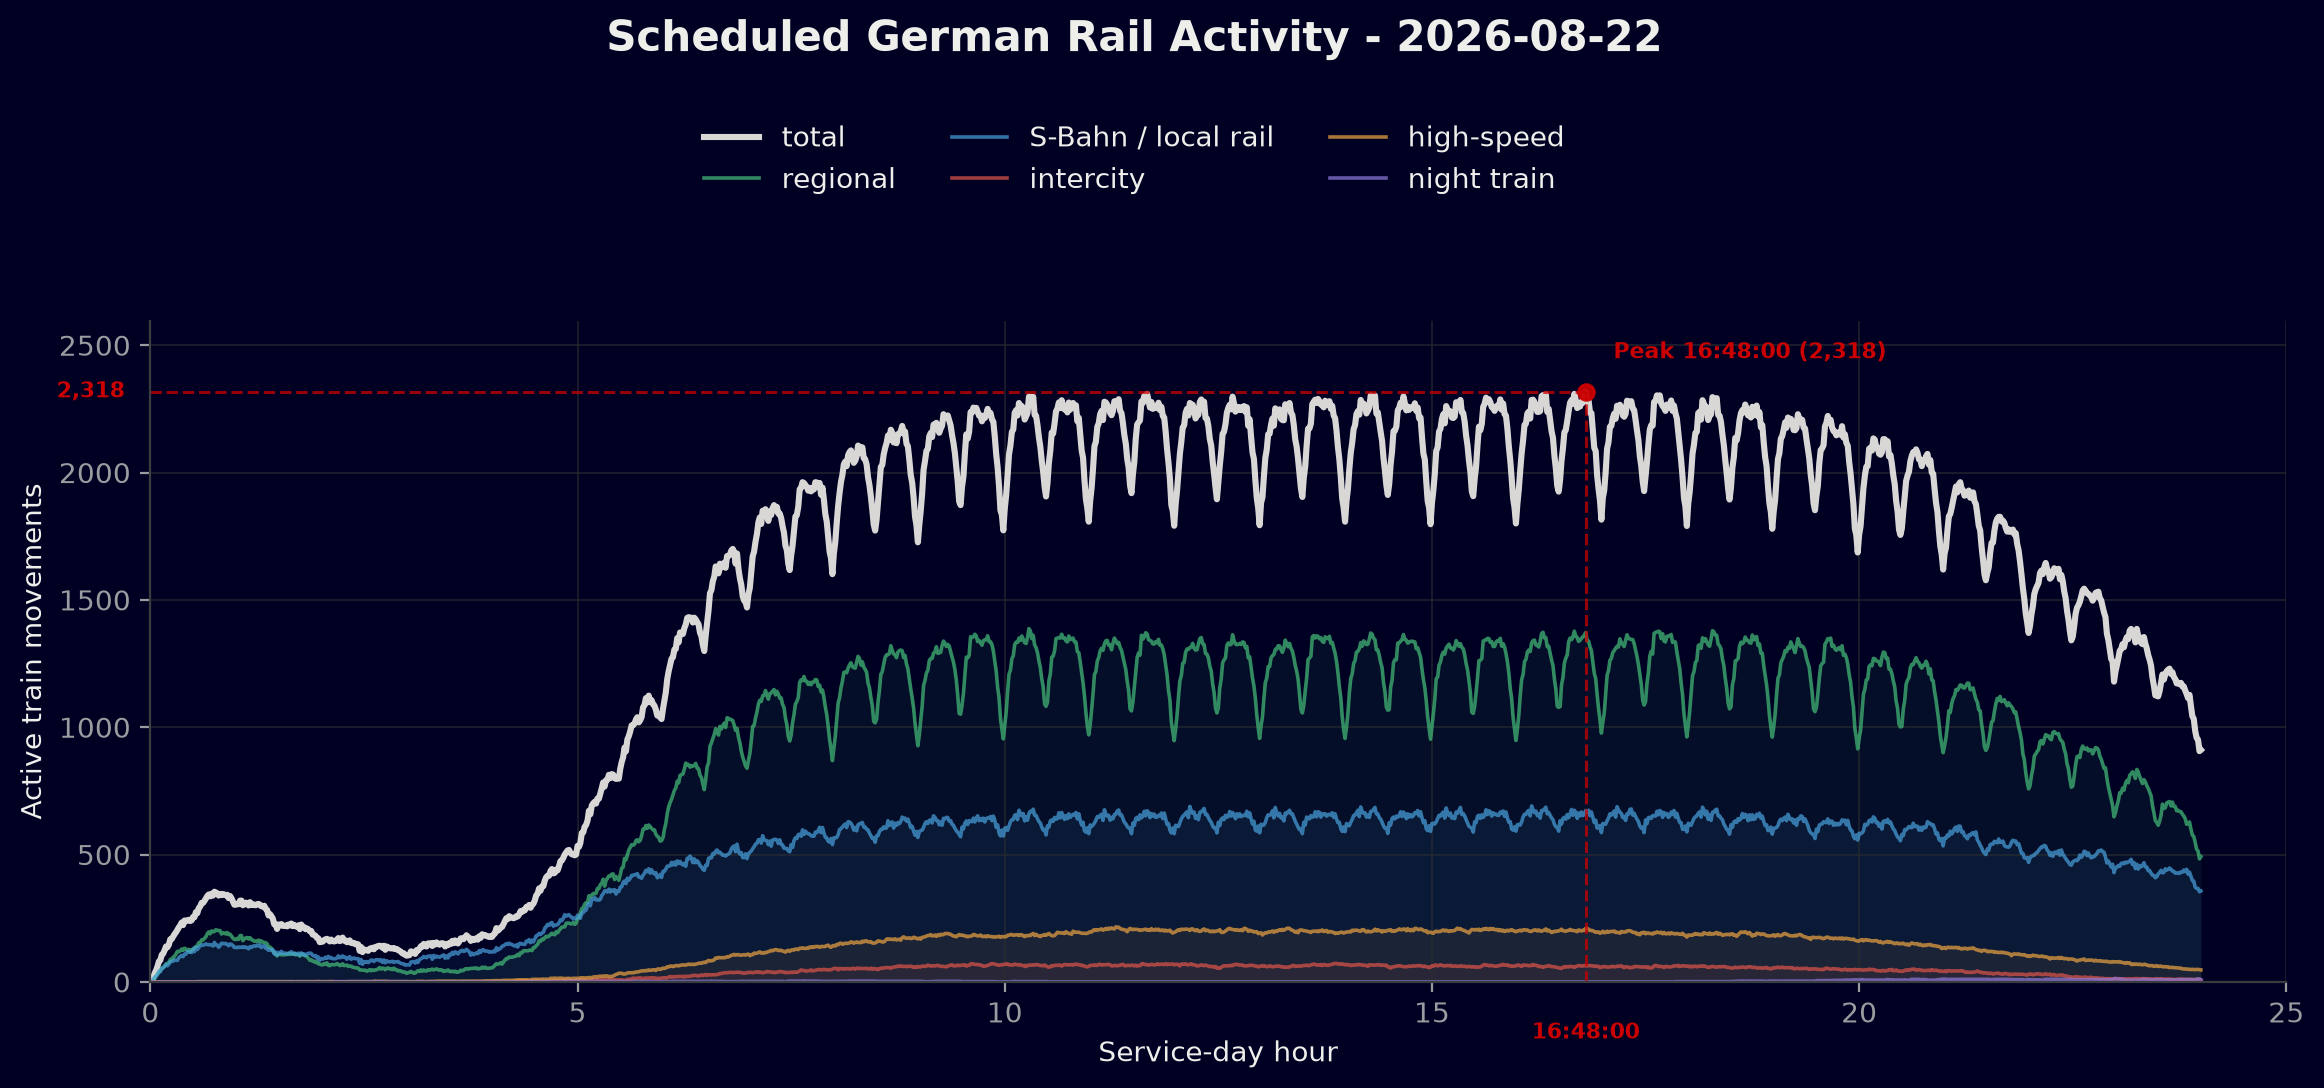

In [28]:
hours = stats["service_seconds"] / 3600
peak_colour = "#CB0101"

fig, ax = plt.subplots(figsize=(12, 5.8), dpi=200)
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.plot(
    hours,
    stats["total"],
    color=TOTAL,
    linewidth=2.2,
    alpha=0.9,
    label="total",
)

for column in [category for category in CATEGORY_ORDER if category in stats.columns]:
    ax.fill_between(
        hours,
        stats[column],
        color=CATEGORY_COLORS[column],
        alpha=0.075,
        linewidth=0,
    )
    ax.plot(
        hours,
        stats[column],
        color=CATEGORY_COLORS[column],
        linewidth=1.3,
        alpha=0.7,
        label=CATEGORY_LABELS[column],
    )

peak = stats.loc[stats["total"].idxmax()]
peak_hour = peak["service_seconds"] / 3600
peak_total = int(peak["total"])

ax.set_xlim(0, 25)
ax.set_ylim(0, stats["total"].max() * 1.12)

ax.scatter(
    [peak_hour],
    [peak_total],
    color=peak_colour,
    alpha=0.95,
    s=32,
    zorder=5,
)

ax.axvline(
    peak_hour,
    ymin=0,
    ymax=peak_total / ax.get_ylim()[1],
    color=peak_colour,
    linewidth=1.1,
    alpha=0.75,
    linestyle="--",
    zorder=2,
)

ax.axhline(
    peak_total,
    xmin=0,
    xmax=(peak_hour - ax.get_xlim()[0]) / (ax.get_xlim()[1] - ax.get_xlim()[0]),
    color=peak_colour,
    linewidth=1.1,
    alpha=0.75,
    linestyle="--",
    zorder=2,
)

ax.annotate(
    f"Peak {peak['service_time']} ({peak_total:,})",
    xy=(peak_hour, peak_total),
    xytext=(10, 12),
    textcoords="offset points",
    fontsize=8,
    color=peak_colour,
    fontweight="bold",
)

ax.text(
    peak_hour,
    -0.06,
    peak["service_time"],
    color=peak_colour,
    fontsize=8,
    fontweight="bold",
    ha="center",
    va="top",
    transform=ax.get_xaxis_transform(),
)

ax.text(
    -0.012,
    peak_total,
    f"{peak_total:,}",
    color=peak_colour,
    fontsize=8,
    fontweight="bold",
    ha="right",
    va="center",
    transform=ax.get_yaxis_transform(),
)

fig.suptitle(
    f"Scheduled German Rail Activity - {SERVICE_DATE:%Y-%m-%d}",
    fontsize=15,
    fontweight="bold",
    color=FOREGROUND,
    y=0.98,
)

legend = fig.legend(
    frameon=False,
    ncols=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
)

for text in legend.get_texts():
    text.set_color(FOREGROUND)

ax.set_xlabel("Service-day hour")
ax.set_ylabel("Active train movements")

ax.xaxis.label.set_color(FOREGROUND)
ax.yaxis.label.set_color(FOREGROUND)
ax.tick_params(colors=MUTED)

ax.grid(True, color=GRID, linewidth=0.6, alpha=0.72)

for name, spine in ax.spines.items():
    if name in {"top", "right"}:
        spine.set_visible(False)
    else:
        spine.set_color(SPINE)

fig.subplots_adjust(
    top=0.72,
    left=0.09,
    right=0.98,
    bottom=0.15,
)

plt.show()

Scheduled rail activity peaks at 16:48 with 2,318 active movements. The day is dominated by regional and S-Bahn/local services, while intercity and high-speed trains add a smaller but steady long-distance layer. The curve shows a strong morning rise, sustained daytime operation, and a clear evening decline after 20:00.

## Train category Share

In [29]:
daily_category_stats = (
    active_trips.groupby("category")
    .agg(
        scheduled_trips=("trip_id", "nunique"),
        route_count=("route_id", "nunique"),
    )
    .reset_index()
)

daily_category_stats["category_label"] = daily_category_stats["category"].map(CATEGORY_LABELS)

daily_category_stats["trip_share"] = (
    daily_category_stats["scheduled_trips"]
    / daily_category_stats["scheduled_trips"].sum()
    * 100
)

daily_category_stats["route_share"] = (
    daily_category_stats["route_count"]
    / daily_category_stats["route_count"].sum()
    * 100
)

daily_category_stats = daily_category_stats.sort_values(
    "scheduled_trips",
    ascending=True,
)

daily_category_stats

,category,scheduled_trips,route_count,category_label,trip_share,route_share
2,night_train,30,8,night train,0.078204,0.851970
1,intercity,399,39,intercity,1.040119,4.153355
0,high_speed,758,60,high-speed,1.975965,6.389776
4,s_bahn_local,15694,174,S-Bahn / local rail,40.911342,18.530351
3,regional,21480,658,regional,55.994369,70.074547


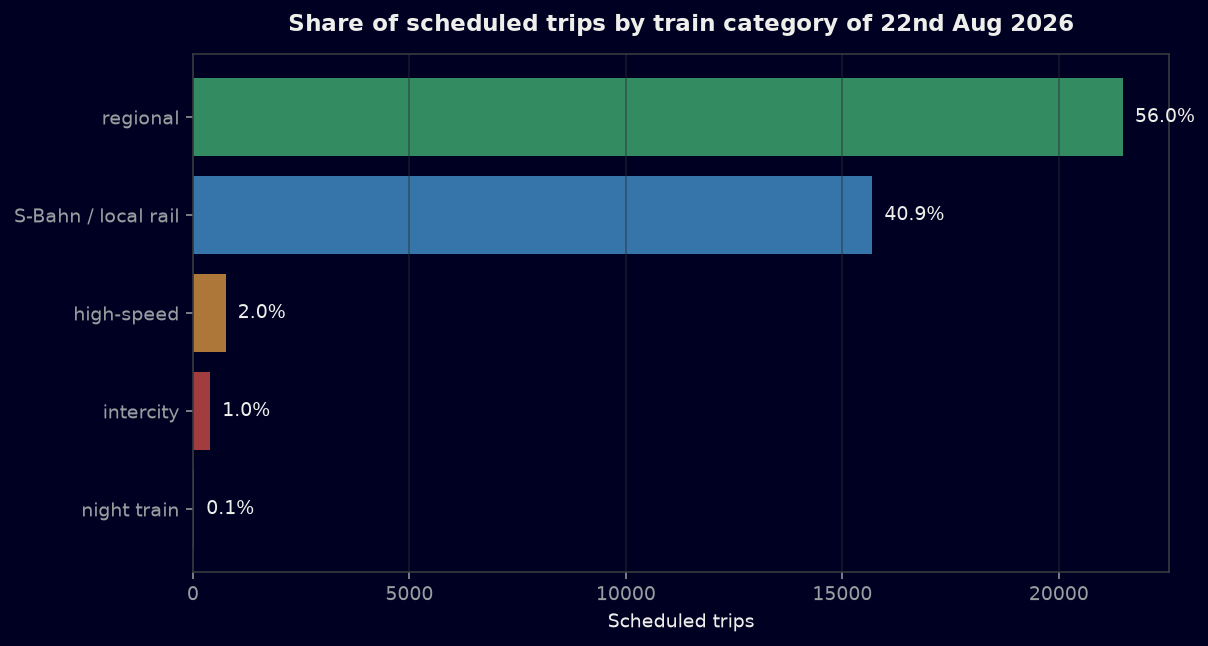

In [31]:
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=140)
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.barh(
    daily_category_stats["category_label"],
    daily_category_stats["scheduled_trips"],
    color=[CATEGORY_COLORS[column] for column in daily_category_stats["category"]],
    alpha=0.72,
)

for index, row in enumerate(daily_category_stats.itertuples(index=False)):
    ax.text(
        row.scheduled_trips,
        index,
        f"  {row.trip_share:.1f}%",
        va="center",
        color=FOREGROUND,
    )

ax.set_title("Share of scheduled trips by train category of 22nd Aug 2026", fontweight="bold", pad=12)
ax.set_xlabel("Scheduled trips")
ax.grid(axis="x", color=GRID, alpha=0.55)

for spine in ax.spines.values():
    spine.set_color(SPINE)

plt.show()

In [32]:
category_columns = [category for category in CATEGORY_ORDER if category in stats.columns]

service_intensity = pd.DataFrame({
    "category": category_columns,
    "category_label": [CATEGORY_LABELS[column] for column in category_columns],
    "train_minutes": [stats[column].sum() for column in category_columns],
})

service_intensity["train_hours"] = service_intensity["train_minutes"] / 60
service_intensity["share"] = (
    service_intensity["train_hours"]
    / service_intensity["train_hours"].sum()
    * 100
)

service_intensity = service_intensity.sort_values("train_hours", ascending=True)

service_intensity

,category,category_label,train_minutes,train_hours,share
4,night_train,night train,3194,53.233333,0.142385
2,intercity,intercity,56114,935.233333,2.501509
3,high_speed,high-speed,178364,2972.733333,7.951298
1,s_bahn_local,S-Bahn / local rail,703860,11731.000000,31.377413
0,regional,regional,1301674,21694.566667,58.027395


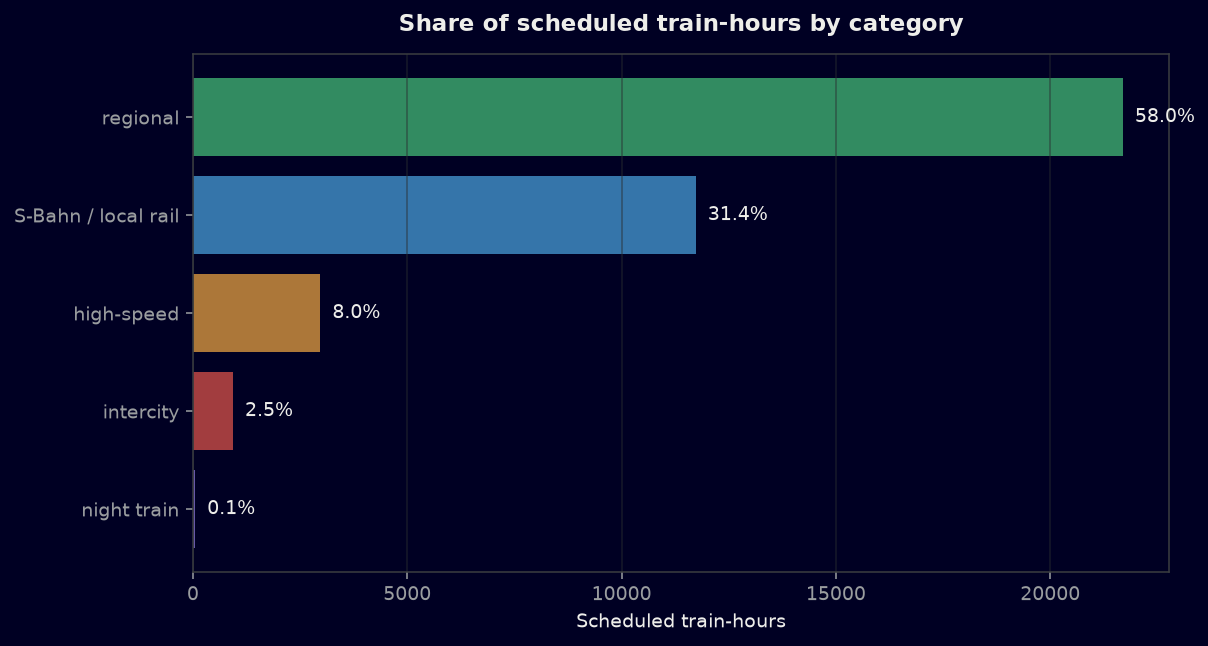

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=140)
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.barh(
    service_intensity["category_label"],
    service_intensity["train_hours"],
    color=[CATEGORY_COLORS[column] for column in service_intensity["category"]],
    alpha=0.72,
)

for index, row in enumerate(service_intensity.itertuples(index=False)):
    ax.text(
        row.train_hours,
        index,
        f"  {row.share:.1f}%",
        va="center",
        color=FOREGROUND,
    )

ax.set_title("Share of scheduled train-hours by category", fontweight="bold", pad=12)
ax.set_xlabel("Scheduled train-hours")
ax.grid(axis="x", color=GRID, alpha=0.55)

for spine in ax.spines.values():
    spine.set_color(SPINE)

plt.show()

Regional and S-Bahn/local services dominate scheduled rail activity, together accounting for 89.4% of total train-hours. Long-distance services make up a much smaller share, with high-speed and intercity trains contributing 10.5% combined, while night trains are marginal in the daily total.

## Load Active GTFS Trips and Stops

This section reads the GTFS feed files directly, filters the active services for the service date, keeps rail route types, and attaches the category labels used by the renderers.

In [35]:
def load_active_feed(feed, service_date):
    feed_path = feed["path"]
    service_ids = active_service_ids(feed_path, service_date)

    routes = pd.read_csv(
        feed_path / "routes.txt",
        dtype={"route_id": "string", "route_type": "string", "route_short_name": "string"},
        usecols=lambda column: column in {"route_id", "route_type", "route_short_name", "route_long_name"},
    )
    routes = routes[routes["route_type"].isin(RAIL_ROUTE_TYPES)].copy()
    routes["category"] = routes.apply(
        lambda row: classify_route(row.get("route_short_name"), route_type=row.get("route_type"), feed_label=feed["label"]),
        axis=1,
    )

    trips = pd.read_csv(
        feed_path / "trips.txt",
        dtype={"route_id": "string", "service_id": "string", "trip_id": "string"},
    )
    trips = trips[trips["service_id"].isin(service_ids)].merge(routes, on="route_id", how="inner")
    trips["feed"] = feed["label"]

    stop_times = pd.read_csv(
        feed_path / "stop_times.txt",
        dtype={"trip_id": "string", "stop_id": "string"},
        usecols=["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"],
    )
    stops = pd.read_csv(
        feed_path / "stops.txt",
        dtype={"stop_id": "string"},
        usecols=["stop_id", "stop_name", "stop_lat", "stop_lon"],
    )
    stop_events = stop_times.merge(
        trips[["trip_id", "route_id", "route_short_name", "category", "feed"]],
        on="trip_id",
        how="inner",
    ).merge(stops, on="stop_id", how="inner")

    return routes, trips, stop_events


route_tables = []
trip_tables = []
stop_event_tables = []
feed_summary_rows = []

for feed in default_feeds(DATA_DIR):
    routes, trips, stop_events = load_active_feed(feed, SERVICE_DATE)
    route_tables.append(routes.assign(feed=feed["label"]))
    trip_tables.append(trips)
    stop_event_tables.append(stop_events)
    feed_summary_rows.append(
        {
            "type_of_feed": feed["label"],
            "active_services": len(active_service_ids(feed["path"], SERVICE_DATE)),
            "rail_routes": routes["route_id"].nunique(),
            "active_trips": trips["trip_id"].nunique(),
            "stop_events": len(stop_events),
            "unique_stops": stop_events["stop_id"].nunique(),
        }
    )

active_routes = pd.concat(route_tables, ignore_index=True)
active_trips = pd.concat(trip_tables, ignore_index=True)
active_stop_events = pd.concat(stop_event_tables, ignore_index=True)

feed_summary = pd.DataFrame(feed_summary_rows)
display(feed_summary)

,type_of_feed,active_services,rail_routes,active_trips,stop_events,unique_stops
0,intercity,226,95,1063,9373,573
1,regional,1402,963,37298,493890,8066


# Major stations based on GTFS data

This is an exploratory hub signal based on scheduled stop events and unique active trips. It is not yet a passenger-volume measure.

To estimate major rail hubs, I used scheduled stop activity from the GTFS feed. For each station name, I counted the number of unique train trips stopping there on the selected service date, the total number of scheduled stop events, and the number of routes serving that station. This should be read as “scheduled train activity”, not passenger volume or real station usage. The GTFS data does not include passenger counts, cancellations, delays, or platform-level operations.

In [9]:
hub_candidates = (
    active_stop_events.groupby("stop_name")
    .agg(
        active_trips=("trip_id", "nunique"),
        stop_events=("trip_id", "size"),
        route_count=("route_id", "nunique"),
        train_categories=("category", "nunique"),
        latitude=("stop_lat", "mean"),
        longitude=("stop_lon", "mean"),
    )
    .reset_index()
    .sort_values(
        ["active_trips", "route_count", "stop_events"],
        ascending=False
    )
)

hub_candidates.head(20)

,stop_name,active_trips,stop_events,route_count,train_categories,latitude,longitude
5827,S Ostkreuz Bhf,1513,1513,8,1,52.503335,13.468951
5883,S+U Friedrichstr. Bhf,1352,1352,8,1,52.520429,13.386786
5884,S+U Gesundbrunnen Bhf,1159,1159,6,1,52.549173,13.389901
6522,Stuttgart Hbf,1089,1089,35,4,48.784780,9.182757
3707,Köln Hbf,1043,1043,34,4,50.943030,6.958729
2022,Frankfurt(Main)Hbf,981,981,50,4,50.106680,8.662828
5879,S+U Berlin Hauptbahnhof,980,980,5,1,52.525556,13.369400
2610,Hamburg Hbf (S-Bahn),967,967,4,1,53.552810,10.007921
5859,S Südkreuz Bhf,962,962,5,1,52.475957,13.365295
2600,Hamburg Berliner Tor,953,953,2,1,53.552870,10.024630


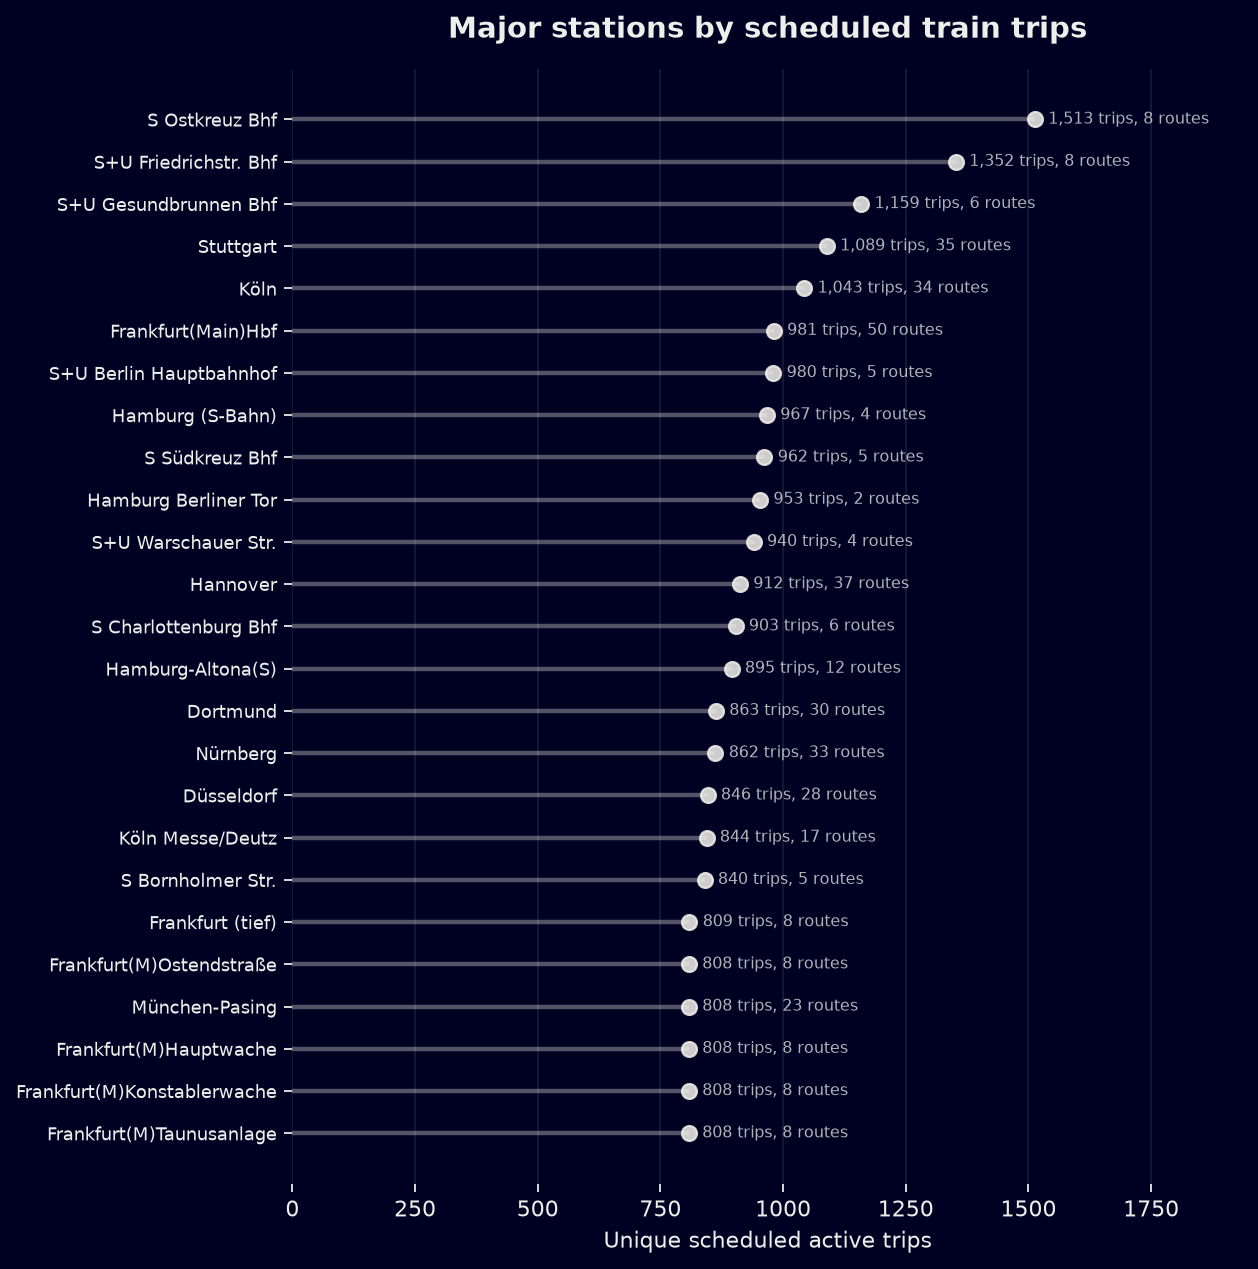

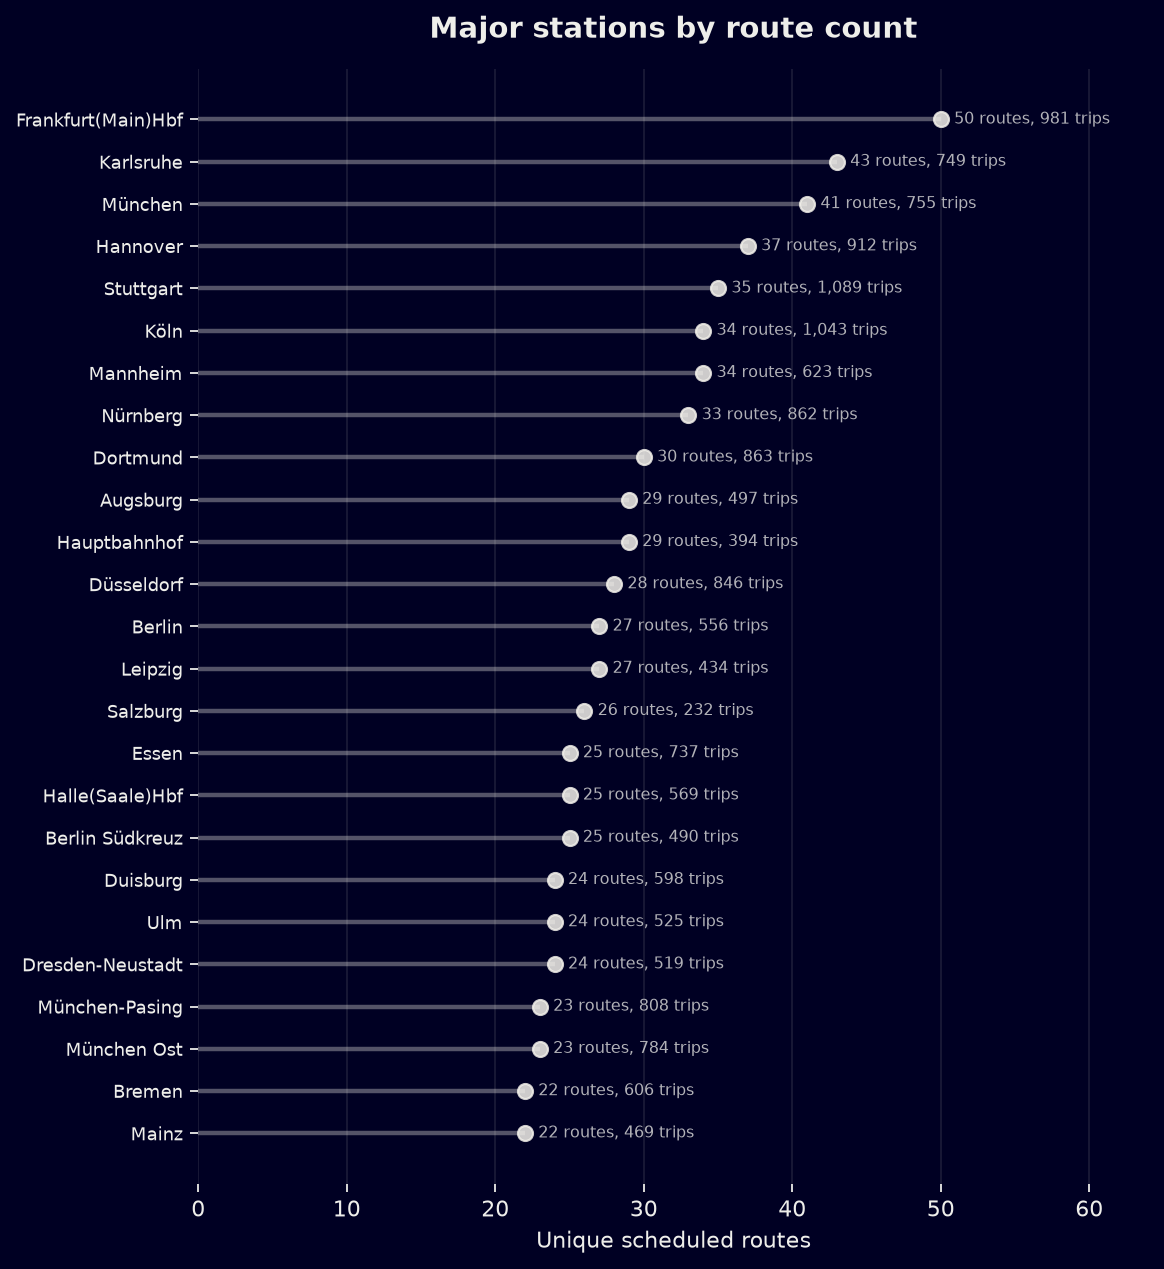

In [36]:
top_n = 25


def hub_ranking_plot(metric, metric_label, title, label_template):
    plot_df = hub_candidates.nlargest(top_n, metric).copy()
    plot_df["display_name"] = (
        plot_df["stop_name"]
        .str.replace(" Hbf", "", regex=False)
        .str.replace(" Bahnhof", "", regex=False)
    )
    plot_df = plot_df.sort_values(metric, ascending=True).reset_index(drop=True)
    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(11, 8.5), dpi=160)
    fig.patch.set_facecolor(BACKGROUND)
    ax.set_facecolor(BACKGROUND)

    ax.hlines(
        y=y,
        xmin=0,
        xmax=plot_df[metric],
        color=TOTAL,
        alpha=0.35,
        linewidth=2,
    )
    ax.scatter(
        plot_df[metric],
        y,
        s=45,
        color=TOTAL,
        alpha=0.85,
        zorder=3,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["display_name"], fontsize=8, color=FOREGROUND)

    x_offset = plot_df[metric].max() * 0.018
    for i, row in plot_df.iterrows():
        ax.text(
            row[metric] + x_offset,
            i,
            label_template(row),
            va="center",
            fontsize=7,
            color=FOREGROUND,
            alpha=0.75,
        )

    ax.set_title(title, fontweight="bold", fontsize=13, color=FOREGROUND, pad=14)
    ax.set_xlabel(metric_label, color=FOREGROUND)
    ax.set_ylabel("")
    ax.tick_params(axis="x", colors=FOREGROUND)
    ax.tick_params(axis="y", colors=FOREGROUND)
    ax.grid(axis="x", alpha=0.15)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(0, plot_df[metric].max() * 1.28)
    fig.subplots_adjust(left=0.28, right=0.82, top=0.91, bottom=0.09)
    plt.show()


hub_ranking_plot(
    metric="active_trips",
    metric_label="Unique scheduled active trips",
    title="Major stations by scheduled train trips",
    label_template=lambda row: f'{int(row["active_trips"]):,} trips, {int(row["route_count"]):,} routes',
)

hub_ranking_plot(
    metric="route_count",
    metric_label="Unique scheduled routes",
    title="Major stations by route count",
    label_template=lambda row: f'{int(row["route_count"]):,} routes, {int(row["active_trips"]):,} trips',
)


# Hubs based on InfraGO

Disclaimer on “hub” definition

DB InfraGO does not explicitly publish a list called “railway hubs” for this purpose. Therefore, the hub analysis in this notebook should be understood as an approximate and externally informed classification, not as an official DB hub ranking.

Two DB InfraGO sources were used as context. 
- First, DB InfraGO publishes prioritisation maps for major disruptions on the rail network ([link](https://www.dbinfrago.com/web/schienennetz/betrieb/informationen-betriebssituation/grossstoerungen-11092312)). These maps are intended to support operational prioritisation during disruptions and are explicitly described as orientation material, not legally binding classifications. 
- Second, DB InfraGO classifies stations into price classes ([link](https://www.dbinfrago.com/web-en/stations-12541102)). In that system, DB InfraGO states that top-category stations, formerly categories 1 and 2, are primarily major junction stations, while lower categories generally have lower traffic significance or simpler infrastructure.

Based on this, the selected stations are treated here as major railway-node candidates rather than officially defined “hubs”. The GTFS data is then used only to measure scheduled rail activity at these stations, such as unique active trips, stop events, route count, and service-category mix. These values do not represent passenger volume, real-time operations, delays, cancellations, or official station importance.

### I. DB InfraGO publishes prioritisation maps for major disruptions on the rail network

,location,matched_stops,top_stop_name,active_trips,stop_events,route_count,train_categories,latitude,longitude
12,Berlin,40,S+U Berlin Hauptbahnhof,3660,6125,62,4,52.506579,12.685077
8,München,50,München-Pasing,2544,12014,72,4,48.157665,11.561471
1,Hamburg,61,Hamburg Hbf (S-Bahn),2324,23218,41,4,53.553363,9.988566
5,Frankfurt (Main),9,Frankfurt(Main)Hbf,1695,3294,63,4,50.103009,8.659198
6,Karlsruhe,67,Karlsruhe Hbf,1581,14630,56,4,49.022265,8.417360
7,Stuttgart,15,Stuttgart Hbf,1391,3695,43,4,48.856641,9.265049
4,Köln,27,Köln Hbf,1250,5795,36,4,50.947743,6.968001
9,Nürnberg,17,Nürnberg Hbf,1074,2635,36,4,49.399434,10.983446
3,Dortmund,44,Dortmund Hbf,953,4043,31,4,51.514167,7.456438
2,Hannover,13,Hannover Hbf,912,2365,37,4,52.380615,9.739827


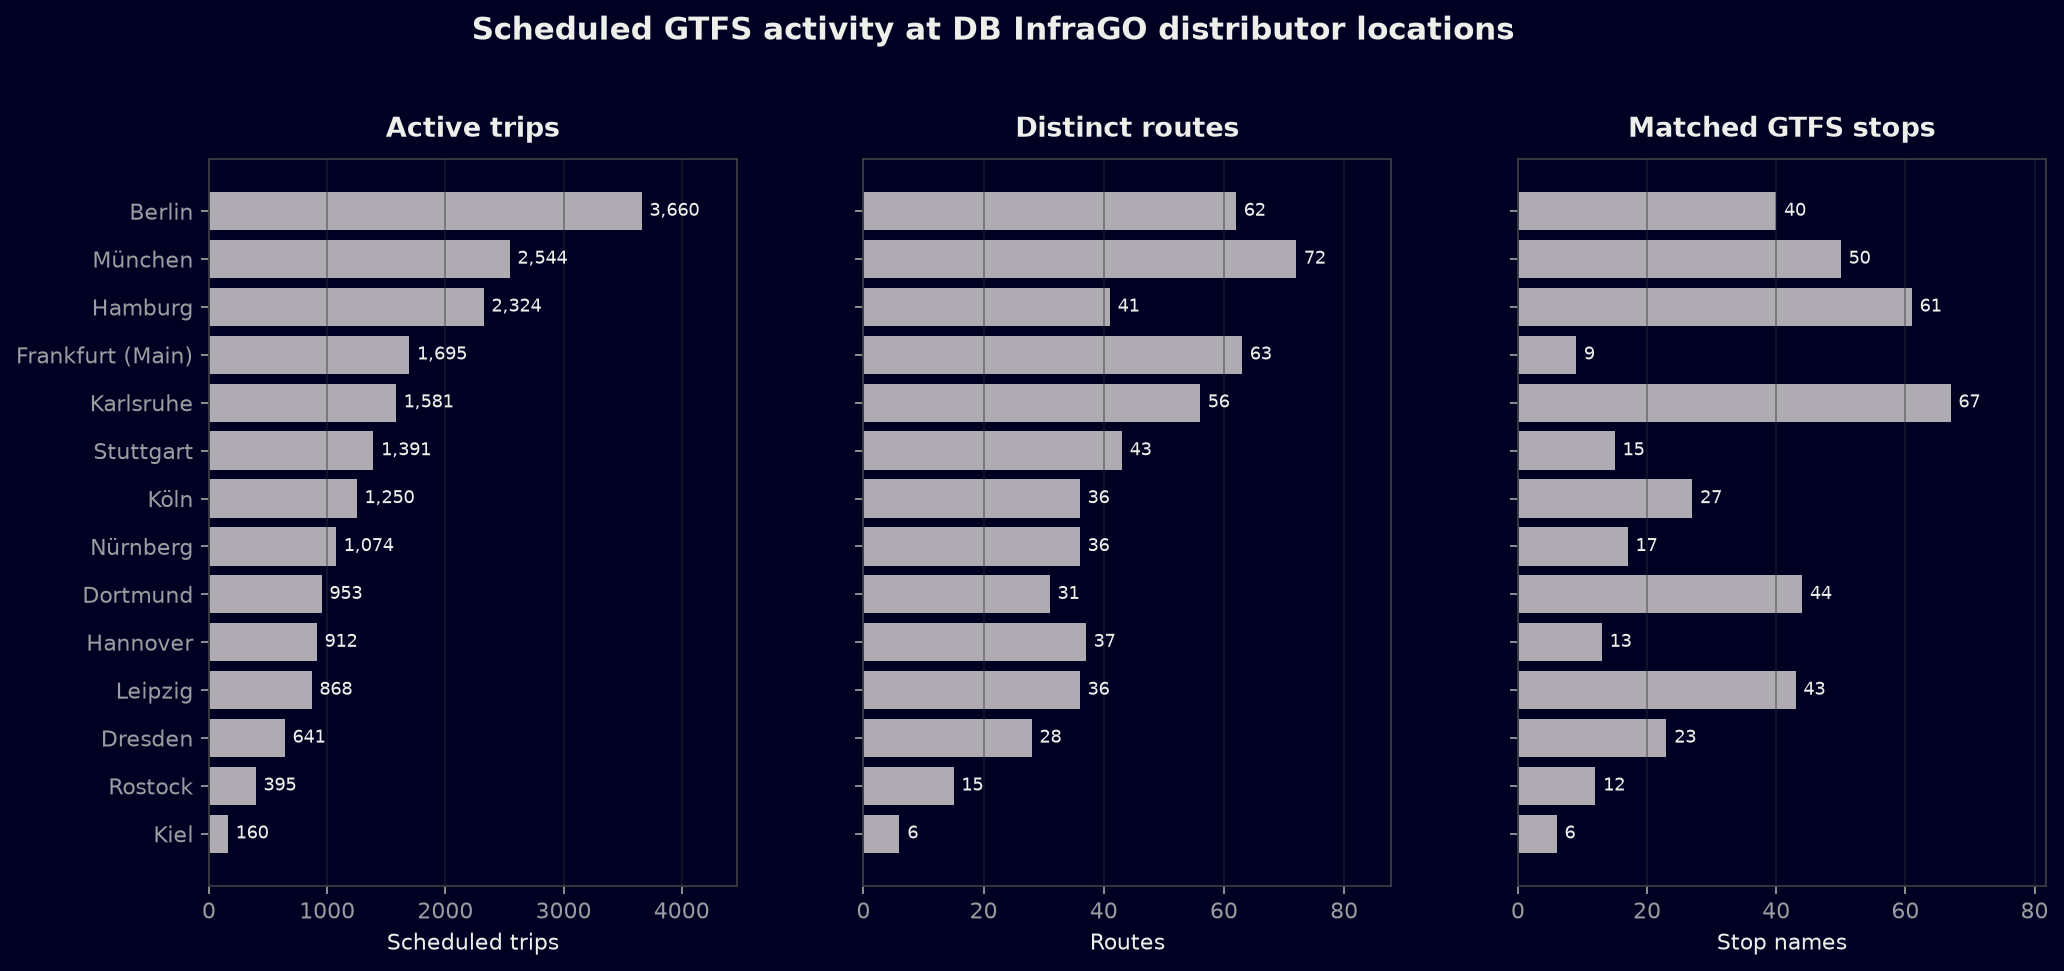

In [43]:
db_infrago_locations = [
    "Kiel",
    "Hamburg",
    "Hannover",
    "Dortmund",
    "Köln",
    "Frankfurt (Main)",
    "Karlsruhe",
    "Stuttgart",
    "München",
    "Nürnberg",
    "Dresden",
    "Leipzig",
    "Berlin",
    "Rostock",
]

match_terms = {
    "Kiel": ["Kiel"],
    "Hamburg": ["Hamburg"],
    "Hannover": ["Hannover"],
    "Dortmund": ["Dortmund"],
    "Köln": ["Köln"],
    "Frankfurt (Main)": ["Frankfurt", "Main"],
    "Karlsruhe": ["Karlsruhe"],
    "Stuttgart": ["Stuttgart"],
    "München": ["München"],
    "Nürnberg": ["Nürnberg"],
    "Dresden": ["Dresden"],
    "Leipzig": ["Leipzig"],
    "Berlin": ["Berlin"],
    "Rostock": ["Rostock"],
}


def matching_stop_events(terms):
    matched = active_stop_events.copy()
    for term in terms:
        matched = matched[
            matched["stop_name"].str.contains(term, case=False, na=False, regex=False)
        ]
    return matched


rows = []

for location in db_infrago_locations:
    matched = matching_stop_events(match_terms[location])

    if matched.empty:
        rows.append(
            {
                "location": location,
                "matched_stops": 0,
                "top_stop_name": None,
                "active_trips": 0,
                "stop_events": 0,
                "route_count": 0,
                "train_categories": 0,
                "latitude": np.nan,
                "longitude": np.nan,
            }
        )
        continue

    top_stop = (
        matched.groupby("stop_name")
        .agg(
            active_trips=("trip_id", "nunique"),
            stop_events=("trip_id", "size"),
        )
        .reset_index()
        .sort_values(["active_trips", "stop_events"], ascending=False)
        .iloc[0]
    )

    rows.append(
        {
            "location": location,
            "matched_stops": matched["stop_name"].nunique(),
            "top_stop_name": top_stop["stop_name"],
            "active_trips": matched["trip_id"].nunique(),
            "stop_events": len(matched),
            "route_count": matched["route_id"].nunique(),
            "train_categories": matched["category"].nunique(),
            "latitude": matched["stop_lat"].mean(),
            "longitude": matched["stop_lon"].mean(),
        }
    )


db_infrago_activity = pd.DataFrame(rows).sort_values(
    ["active_trips", "route_count", "stop_events"],
    ascending=False,
)

display(db_infrago_activity)

plot_df = db_infrago_activity.sort_values("active_trips", ascending=True).copy()
y = np.arange(len(plot_df))

fig, axes = plt.subplots(ncols=3, figsize=(14, 6.4), dpi=160, sharey=True)
fig.patch.set_facecolor(BACKGROUND)

metrics = [
    ("active_trips", "Active trips", "Scheduled trips"),
    ("route_count", "Distinct routes", "Routes"),
    ("matched_stops", "Matched GTFS stops", "Stop names"),
]

for ax, (metric, title, xlabel) in zip(axes, metrics):
    ax.set_facecolor(BACKGROUND)

    ax.barh(
        plot_df["location"],
        plot_df[metric],
        color=TOTAL,
        alpha=0.72,
    )

    x_offset = max(plot_df[metric].max() * 0.018, 0.5)

    for index, value in enumerate(plot_df[metric]):
        ax.text(
            value + x_offset,
            index,
            f"{int(value):,}",
            va="center",
            color=FOREGROUND,
            fontsize=8,
        )

    ax.set_title(title, color=FOREGROUND, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, color=FOREGROUND)
    ax.tick_params(axis="x", colors=MUTED)
    ax.tick_params(axis="y", colors=MUTED)
    ax.grid(axis="x", color=GRID, alpha=0.45)

    max_value = plot_df[metric].max()
    ax.set_xlim(0, max_value * 1.22 if max_value else 1)

    for spine in ax.spines.values():
        spine.set_color(SPINE)

fig.suptitle(
    "Scheduled GTFS activity at DB InfraGO distributor locations",
    color=FOREGROUND,
    fontweight="bold",
    fontsize=14,
    y=0.98,
)

fig.subplots_adjust(
    left=0.15,
    right=0.97,
    top=0.84,
    bottom=0.13,
    wspace=0.24,
)

plt.show()

### II. DB InfraGO classifies stations into price classes


Extracted 5,412 station-price rows from List-of-Station-Prices-2026-valid-as-of-01-January-2026-data.pdf


,station_no,sdpt_competent_entities,station,price_class,federal_state,local_rail_price_eur,long_distance_price_eur,comment,pdf_page
0,1,go.R,Aachen Hbf,2,Nordrhein-Westfalen,17.28,49.71,,1
1,7205,go.R,Aachen Schanz,5,Nordrhein-Westfalen,2.78,7.88,,1
2,3,go.R,Aachen West,5,Nordrhein-Westfalen,2.78,7.88,,1
3,2,go.R,Aachen-Rothe Erde,4,Nordrhein-Westfalen,2.69,7.51,,1
4,4,VM BW,Aalen Hbf,3,Baden-Württemberg,5.36,15.12,,1


,location,matched_price_rows,best_price_class,best_price_station,median_price_class,local_rail_price_eur,long_distance_price_eur
12,Berlin,64,1,Berlin Gesundbrunnen,4.0,19.45,55.96
8,München,49,1,München Hbf,4.0,21.67,62.37
11,Leipzig,46,1,Leipzig Hbf,5.5,30.84,88.79
3,Dortmund,44,1,Dortmund Hbf,6.0,15.74,45.31
4,Köln,26,1,Köln Hbf,4.0,18.27,52.59
10,Dresden,24,1,Dresden Hbf,5.0,35.72,102.83
7,Stuttgart,23,1,Stuttgart Hbf,4.0,25.00,71.96
9,Nürnberg,22,1,Nürnberg Hbf,5.0,21.67,62.37
5,Frankfurt (Main),20,1,Frankfurt (Main) Hbf,3.0,28.12,80.93
2,Hannover,12,1,Hannover Hbf,4.0,24.69,71.09


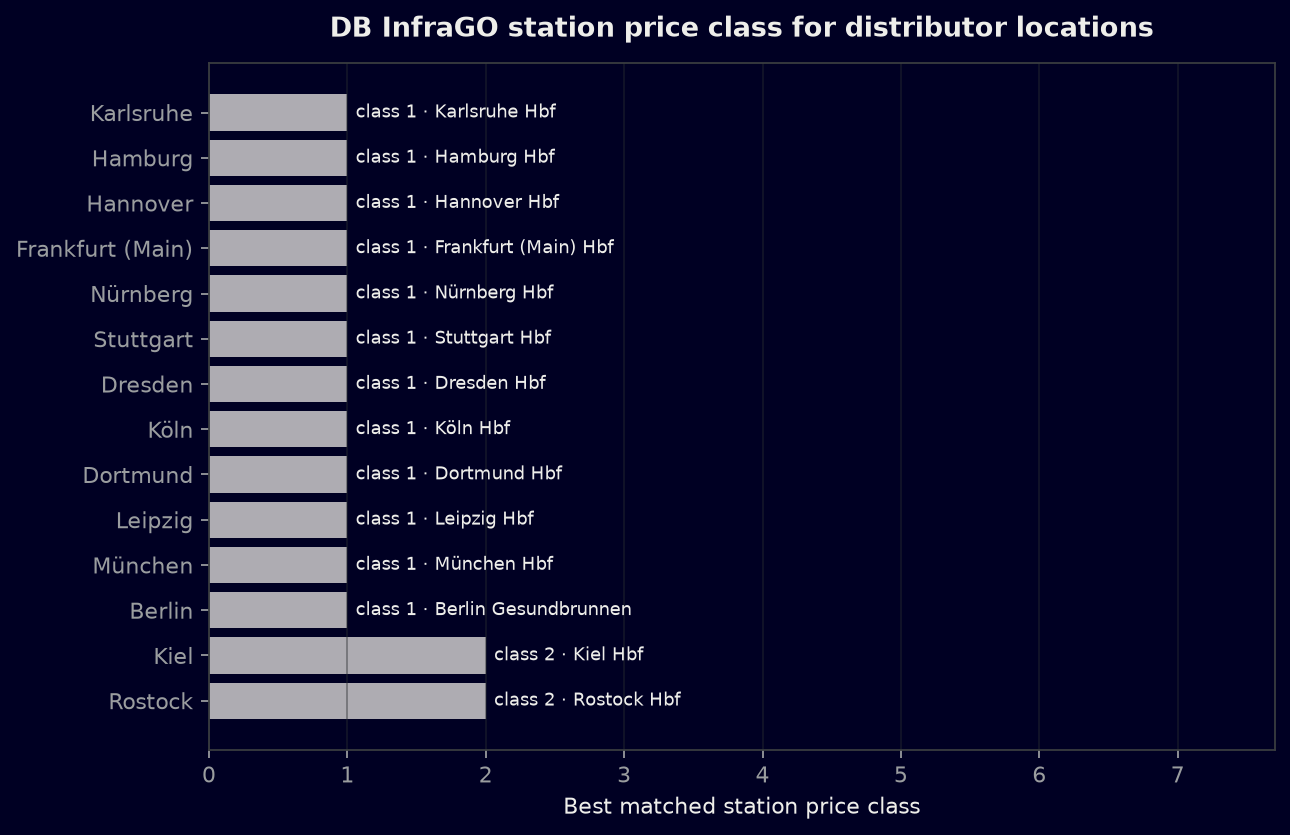

In [42]:
import pdfplumber

station_price_pdf = DATA_DIR / "List-of-Station-Prices-2026-valid-as-of-01-January-2026-data.pdf"

if not station_price_pdf.exists():
    raise FileNotFoundError(f"Missing station price PDF: {station_price_pdf}")


def parse_euro(value):
    value = str(value).replace("€", "").replace(".", "").replace(",", ".").strip()
    return pd.to_numeric(value, errors="coerce")


station_price_rows = []
station_price_columns = [
    "station_no",
    "sdpt_competent_entities",
    "station",
    "price_class",
    "federal_state",
    "local_rail_price_eur",
    "long_distance_price_eur",
    "comment",
]

with pdfplumber.open(station_price_pdf) as pdf:
    for page_number, page in enumerate(pdf.pages, start=1):
        for table in page.extract_tables() or []:
            if not table or len(table) < 2:
                continue

            for raw_row in table[1:]:
                if not raw_row or not any(raw_row):
                    continue

                values = [" ".join(str(cell or "").split()) for cell in raw_row]
                if values[0] in {"", "Station-No", "Station- No"}:
                    continue

                values = values[: len(station_price_columns)]
                values += [""] * (len(station_price_columns) - len(values))
                station_price_rows.append(
                    {**dict(zip(station_price_columns, values)), "pdf_page": page_number}
                )

station_prices = pd.DataFrame(station_price_rows)

station_prices["price_class"] = pd.to_numeric(station_prices["price_class"], errors="coerce")
station_prices["local_rail_price_eur"] = station_prices["local_rail_price_eur"].map(parse_euro)
station_prices["long_distance_price_eur"] = station_prices["long_distance_price_eur"].map(parse_euro)
station_prices = station_prices.dropna(subset=["station", "price_class"])
station_prices["price_class"] = station_prices["price_class"].astype(int)

print(f"Extracted {len(station_prices):,} station-price rows from {station_price_pdf.name}")
display(station_prices.head())


def matching_station_prices(terms):
    matched = station_prices.copy()
    for term in terms:
        matched = matched[
            matched["station"].str.contains(term, case=False, na=False, regex=False)
        ]
    return matched


price_class_rows = []
for location in db_infrago_locations:
    matched = matching_station_prices(match_terms[location])

    if matched.empty:
        price_class_rows.append(
            {
                "location": location,
                "matched_price_rows": 0,
                "best_price_class": np.nan,
                "best_price_station": None,
                "median_price_class": np.nan,
                "local_rail_price_eur": np.nan,
                "long_distance_price_eur": np.nan,
            }
        )
        continue

    best = matched.sort_values(["price_class", "station"]).iloc[0]
    price_class_rows.append(
        {
            "location": location,
            "matched_price_rows": len(matched),
            "best_price_class": int(best["price_class"]),
            "best_price_station": best["station"],
            "median_price_class": matched["price_class"].median(),
            "local_rail_price_eur": best["local_rail_price_eur"],
            "long_distance_price_eur": best["long_distance_price_eur"],
        }
    )


db_infrago_price_classes = pd.DataFrame(price_class_rows).sort_values(
    ["best_price_class", "matched_price_rows"], ascending=[True, False]
)

display(db_infrago_price_classes)

plot_df = db_infrago_price_classes.dropna(subset=["best_price_class"]).copy()
plot_df = plot_df.sort_values("best_price_class", ascending=False)

y = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(9, 5.8), dpi=160)
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

ax.barh(
    plot_df["location"],
    plot_df["best_price_class"],
    color=TOTAL,
    alpha=0.72,
)

for index, row in enumerate(plot_df.itertuples(index=False)):
    ax.text(
        row.best_price_class + 0.06,
        index,
        f"class {int(row.best_price_class)} · {row.best_price_station}",
        va="center",
        color=FOREGROUND,
        fontsize=8,
    )

ax.set_title(
    "DB InfraGO station price class for distributor locations",
    color=FOREGROUND,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Best matched station price class", color=FOREGROUND)
ax.tick_params(axis="x", colors=MUTED)
ax.tick_params(axis="y", colors=MUTED)
ax.grid(axis="x", color=GRID, alpha=0.45)
ax.set_xlim(0, 7.7)

for spine in ax.spines.values():
    spine.set_color(SPINE)

fig.subplots_adjust(left=0.18, right=0.92, top=0.88, bottom=0.14)
plt.show()


## Next Analysis Ideas

- Add state boundaries and city labels as separate optional reference layers.
- Compare weekdays versus weekends once more service dates are generated.
- Improve hub scoring by separating passing services from origin/destination events.
- Add `shapes.txt`-based geometry when a suitable feed with route shapes is available.